In [1]:
IBM_RUNTIME_TOKEN = "KBcnbKRlkH-UrGrPDV4v2RpsaToFRDr5XmDl_XewoDSe"
INSTANCE = "crn:v1:bluemix:public:quantum-computing:us-east:a/22dc8fdbcf474c5c8b2faee4cf250adb:6907401c-f66b-4337-8c3f-807e8f1947c4::"
NAME = 'Astryd'

In [3]:
from qiskit_ibm_runtime import QiskitRuntimeService
import numpy as np
import matplotlib.pyplot as plt
from qiskit_device_benchmarking.bench_code.mrb import (
    MirrorQATopo, 
    QuantumAwesomeness,
)
import os, random

# Set up seed
SEED = 123
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

QiskitRuntimeService.save_account(
    token=IBM_RUNTIME_TOKEN,
    instance=INSTANCE,
    name='Astryd',
    set_as_default=True, # Optional
    overwrite=True
)

service = QiskitRuntimeService()
backend = service.backend('ibm_miami')

In [4]:
# MQA notebook: (10000, [2]+[4,10,20,50,100], 20)
# Topo notebook: (1000, [16, 18, 20, 22, 24], 100)

num_qubits=120 # ibm_miami is a 120-qubits square lattice QPU.
shots = 1000 # MQA 10000, topo simulation was 1000
lengths = [2] + [6, 14, 24, 30]
num_samples = 100 # starting from 20, increase it into 100? (Like a simulation?)

# Set up the experiment object
exp = MirrorQATopo(
    range(num_qubits),
    lengths=lengths,
    sampling_algorithm='topo',
    mode='random',
    backend=backend,
    two_qubit_gate_density=0.5,
    num_samples=num_samples,
    initial_entangling_angle=np.pi/2,
    seed=SEED,
)
exp.set_run_options(shots=shots, dd='xx') # dd requires Backend.Target's .pulse_alignments from mirror_rb_experiment
rb_data = exp.run()
# rb_data.block_for_results()

print("Job IDs:", rb_data.job_ids)

IBMRuntimeError: 'Failed to run program: \'400 Client Error: Bad Request for url: https://quantum.cloud.ibm.com/api/v1/jobs. {"errors":[{"code":1370,"message":"The allocation for this instance\\\'s plan on the account is not active.","solution":"Submit the workload to a different plan","more_info":"https://cloud.ibm.com/apidocs/quantum-computing#error-handling"}],"trace":"14c8b12d-e8b8-483b-a0fc-79fe7c2086c6"}\\n\''

In [8]:
job = service.job(rb_data.job_ids[0])
print("Job Status:", job.status())
print("Metrics:", job.metrics())
print("Error:", job.error_message())

Job Status: DONE
Metrics: {'caller': 'qiskit_experiments~framework~base_experiment.py', 'qiskit_version': 'qiskit_ibm_runtime-0.47.0,qiskit-2.4.1*,qiskit_aer-0.17.2,qiskit_experiments-0.14.0', 'timestamps': {'created': '2026-05-29T12:09:36.850247Z', 'finished': '2026-05-29T12:52:36.475591Z', 'running': '2026-05-29T12:09:37.494929Z'}, 'bss': {'seconds': 2007}, 'usage': {'quantum_seconds': 2007, 'seconds': 2007, 'status': 'complete'}}
Error: None


In [9]:
import os, json
import qiskit
import qiskit.qasm2

id = rb_data.job_ids[0]

# Create a folder with the job id as a name
h = f'{id}'
os.makedirs(h, exist_ok=True)

# Save qubit number
with open(f'{h}/{id}_qubits.json', 'w') as f:
    json.dump({'num_qubits': num_qubits}, f)

# Save pairs information
with open(f'{id}_pairs.json', 'w') as f:
    json.dump(exp._pairs, f)

# Save circuits
for i, circ in enumerate(exp.circuits()):
    with open(os.path.join(id, f'circuit_{i}.json'), 'w') as f:
        qiskit.qasm2.dump(circ, f)

### c.f. Optional recovery cell if the server connection was unstable.

In [16]:
# === Recovery: pull this job's results from the server (no QPU re-run) ===
# rb_data.data() came back empty because exp.run() is non-blocking and the
# analysis cells executed before the shots were loaded into rb_data.
# The results ARE on the server (job status DONE), so fetch + reshape them into
# the [{"counts": ..., "metadata": ...}] format mutual_info/evaluate_bot expect.
# (With block_for_results() now in the run cell, a fresh run won't need this.)

JOB_ID = rb_data.job_ids[0] if "rb_data" in dir() and hasattr(rb_data, "job_ids") else "d8ckuvr8amns73bjn1a0"

job = service.job(JOB_ID)
print("status:", job.status())
res = job.result()                       # SamplerV2 PrimitiveResult: one PubResult per circuit
print("result entries:", len(res))

def _counts(pub):
    # circuits measure into creg 'meas' (measure q[j] -> meas[j]); fall back to the lone BitArray
    d = pub.data
    if hasattr(d, "meas"):
        return d.meas.get_counts()
    field = list(d.keys())[0] if hasattr(d, "keys") else next(iter(vars(d)))
    return getattr(d, field).get_counts()

recovered_data = [{"counts": _counts(res[i]), "metadata": {}} for i in range(len(res))]
print("records:", len(recovered_data),
      "| bitstring len:", len(next(iter(recovered_data[0]["counts"]))),
      "| shots[0]:", sum(recovered_data[0]["counts"].values()))

# Sanity: index i must line up with exp._pairs[i] / exp._topo_outcomes[i]
assert len(recovered_data) == len(exp._pairs) == len(exp._topo_outcomes), \
    f"length mismatch: data={len(recovered_data)} pairs={len(exp._pairs)} topo={len(exp._topo_outcomes)}"

# Override rb_data.data() so the analysis cells below run unchanged.
class _RecoveredRB:
    job_ids = [JOB_ID]
    def data(self):
        return recovered_data

rb_data = _RecoveredRB()
print("rb_data.data() now returns", len(rb_data.data()), "records -- re-run the cells below.")

status: DONE
result entries: 500
records: 500 | bitstring len: 120 | shots[0]: 1000
rb_data.data() now returns 500 records -- re-run the cells below.


### Display the results!

/Users/astrydpark/miniconda3/envs/awesomeness/lib/python3.13/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/astrydpark/miniconda3/envs/awesomeness/lib/python3.13/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/astrydpark/miniconda3/envs/awesomeness/lib/python3.13/site-packages/numpy/_core/_methods.py:214: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/astrydpark/miniconda3/envs/awesomeness/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/astrydpark/miniconda3/envs/awesomeness/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype

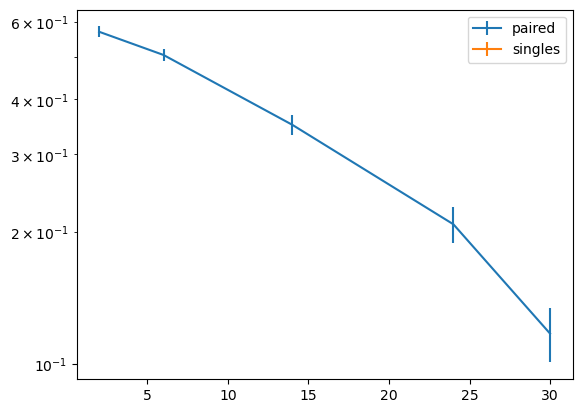

In [10]:
qa = QuantumAwesomeness(exp.backend.coupling_map)
mi = qa.mutual_info(rb_data.data())
mmi = qa.mean_mutual_info(rb_data.data(), exp._pairs)

ys = [[[] for _ in range(len(lengths))] for _ in range(2)] # 'c.f. range(2) for paired' and 'singles'
yerrs = [[], [], []]

for p, pairtype in enumerate(["paired", "singles"]):
    for j, m in enumerate(mmi[pairtype]):
        if m is not np.nan:
            ys[p][j % len(lengths)].append(m)
    for j in range(len(lengths)):
        yerrs[p].append(np.std(ys[p][j]))
        ys[p][j] = np.mean(ys[p][j])

plt.errorbar(lengths, ys[0], yerr=yerrs[0], label="paired")
plt.errorbar(lengths, ys[1], yerr=yerrs[1], label="singles")
plt.yscale("log")
plt.legend()

In [11]:
import pickle
# just added this so that we can import specific job's data
# so that we don't need to re-run the QPU cell again

with open(f"{h}/{id}_data.pkl", "wb") as f:
    pickle.dump(
        {
            "counts": [d["counts"] for d in rb_data.data()],
            "metadata": [d.get("metadata", {}) for d in rb_data.data()],
            "topo_outcomes": exp._topo_outcomes,
            "singles": exp._singles,
            "pairs": exp._pairs,
            "lengths": lengths,
            "num_samples": num_samples,
            "num_qubits": num_qubits,
            "shots": shots,
            "seed": SEED,
        },
        f,
    )


=== ibm_miami bot accuracy ====================================
  Length | P(bot=topo) | P(bot=pairs) | P(topo=pairs) |    N
----------------------------------------------------------------
       2 |       0.760 |        0.760 |         1.000 |  100
       6 |       0.870 |        0.870 |         1.000 |  100
      14 |       0.730 |        0.730 |         1.000 |  100
      24 |       0.410 |        0.410 |         1.000 |  100
      30 |       0.150 |        0.150 |         1.000 |  100


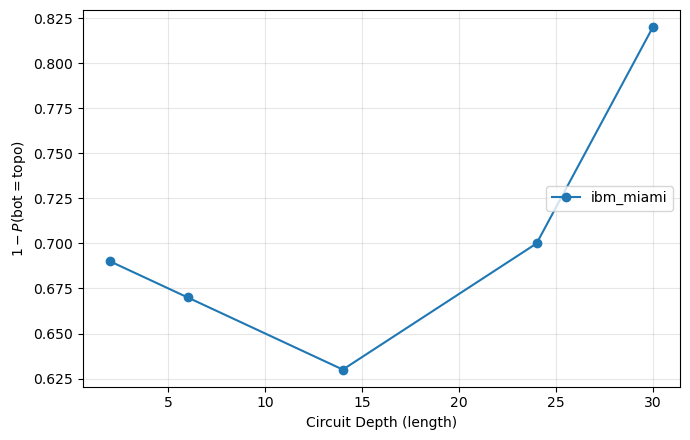

In [ ]:
import json
import networkx as nx
from collections import defaultdict

# ============================================================
# Helpers (ported from mirror_qa_topo.ipynb, hardware-friendly)
# ============================================================
def get_topo_mode(topo_full, fake_qubits):
    """f2f if fake qubits paired together or absent; f2g otherwise."""
    fake_pairs = [p for p in topo_full if any(q in fake_qubits for q in p)]
    if not fake_pairs:
        return "f2f"
    for p in fake_pairs:
        if all(q in fake_qubits for q in p):
            return "f2f"
    return "f2g"


def extract_mi(exp, rb_data, legit_qubits):
    """Mutual-info dicts, one per circuit, restricted to genuine edges."""
    legit_cmap = exp.backend.coupling_map.reduce(range(legit_qubits))
    qa = QuantumAwesomeness(legit_cmap)
    return qa.mutual_info(rb_data.data())


def evaluate_bot(mi, exp, legit_qubits, total_qubits, lengths, verbose=False):
    """MI-MWPM bot vs TopoSampler MWPM vs circuit oracle (exp._pairs)."""
    num_lengths = len(lengths)
    half = legit_qubits // 2
    fake_qubits = set(range(legit_qubits, total_qubits))  # empty on hardware

    bot_topo_ok   = defaultdict(int)
    bot_mode_ok   = defaultdict(int)
    bot_pairs_ok  = defaultdict(int)
    topo_pairs_ok = defaultdict(int)
    totals        = defaultdict(int)

    for i, info in enumerate(mi):
        length = lengths[i % num_lengths]
        sample = i // num_lengths

        topo_full = exp._topo_outcomes[i]
        topo_genuine = sorted(
            tuple(sorted((u, v)))
            for u, v in topo_full
            if u < legit_qubits and v < legit_qubits
        )
        topo_mode = get_topo_mode(topo_full, fake_qubits)

        G = nx.Graph()
        for (u, v), w in info.items():
            G.add_edge(u, v, weight=w)
        bot = sorted(
            tuple(sorted(p))
            for p in nx.max_weight_matching(G, maxcardinality=False, weight="weight")
        )
        bot_mode = "f2f" if len(bot) == half else "f2g"

        pairs_truth = sorted(tuple(sorted(p)) for p in exp._pairs[i])

        bot_topo_ok[length]   += int(set(bot) == set(topo_genuine))
        bot_mode_ok[length]   += int(bot_mode == topo_mode)
        bot_pairs_ok[length]  += int(set(bot) == set(pairs_truth))
        topo_pairs_ok[length] += int(set(topo_genuine) == set(pairs_truth))
        totals[length]        += 1

        if verbose:
            tag = "EXACT" if set(bot) == set(topo_genuine) else (
                "MODE " if bot_mode == topo_mode else "MISS "
            )
            matched_mi = [info[p] for p in bot if p in info]
            mean_mi = float(np.mean(matched_mi)) if matched_mi else float("nan")
            print(f"[{i:3d}] L={length:3d}  sample={sample:3d}  "
                  f"topo={topo_mode}  bot={bot_mode}  [{tag}]  mean-MI={mean_mi:.4f}")

    L = sorted(lengths)
    return {
        "lengths":      L,
        "p_bot_topo":   [bot_topo_ok[l]   / totals[l] for l in L],
        "p_mode_topo":  [bot_mode_ok[l]   / totals[l] for l in L],
        "p_bot_pairs":  [bot_pairs_ok[l]  / totals[l] for l in L],
        "p_topo_pairs": [topo_pairs_ok[l] / totals[l] for l in L],
        "totals":       [totals[l] for l in L],
    }


# ============================================================
# Driver: ibm_miami
# ============================================================
N = num_qubits  # 120; no fake boundary qubits on h/w
mi = extract_mi(exp, rb_data, N)
results_hw = {"miami": evaluate_bot(mi, exp, N, N, lengths, verbose=False)}

# Summary table
L = results_hw["miami"]["lengths"]
print("\n=== ibm_miami bot accuracy ====================================")
print(f"{'Length':>8} | {'P(bot=topo)':>11} | {'P(bot=pairs)':>12} | "
      f"{'P(topo=pairs)':>13} | {'N':>4}")
print("-" * 64)
for k, l in enumerate(L):
    print(f"{l:8d} | {results_hw['miami']['p_bot_topo'][k]:11.3f} | "
          f"{results_hw['miami']['p_bot_pairs'][k]:12.3f} | "
          f"{results_hw['miami']['p_topo_pairs'][k]:13.3f} | "
          f"{results_hw['miami']['totals'][k]:4d}")

# Persist next to the saved circuits
job_id = rb_data.job_ids[0]
with open(f"{job_id}/{job_id}_bot_results.json", "w") as f:
    json.dump(results_hw["miami"], f, indent=2)

In [ ]:
# Plot 1 - P(bot=pairs) vs depth
plt.figure(figsize=(7, 4.5))
plt.plot(
    results_hw["miami"]["lengths"],
    [1 - p for p in results_hw["miami"]["p_bot_pairs"]], 
    marker="o",
    linestyle="-",
    label="ibm_miami",
)
plt.xlabel("Circuit Depth (length)")
plt.ylabel(r"$1 - P(\mathrm{bot} = \mathrm{pairs})$")
plt.grid(True, alpha=0.3)
plt.legend(loc="center right", frameon=True)
plt.tight_layout()
plt.show()

In [ ]:
# Plot 1 - P(bot=pairs) vs depth
plt.figure(figsize=(7, 4.5))
plt.plot(
    results_hw["miami"]["lengths"],
    [1 - p for p in results_hw["miami"]["p_mode_topo"]],  # or 'p_mode_topo'
    marker="o",
    linestyle="-",
    label="ibm_miami",
)
plt.xlabel("Circuit Depth (length)")
plt.ylabel(r"$1 - P(\mathrm{bot} = \mathrm{topo})$")  # or 'topo'
plt.grid(True, alpha=0.3)
plt.legend(loc="center right", frameon=True)
plt.tight_layout()
plt.show()
